# C3 — Threshold Sensitivity Analysis

Uses C2 similarity scores to find the optimal cache threshold.
Sweeps thresholds from 0.70 to 0.98 and plots Precision/Recall/F1.

 Threshold    TP    FP    TN    FN   Precision    Recall      F1
-----------------------------------------------------------------
      0.70     4     2     1     0       0.667     1.000   0.800
      0.75     4     1     2     0       0.800     1.000   0.889
      0.80     2     1     2     2       0.667     0.500   0.571
      0.85     0     1     2     4       0.000     0.000   0.000
      0.88     0     0     3     4       0.000     0.000   0.000
      0.90     0     0     3     4       0.000     0.000   0.000
      0.92     0     0     3     4       0.000     0.000   0.000
      0.94     0     0     3     4       0.000     0.000   0.000
      0.96     0     0     3     4       0.000     0.000   0.000
      0.98     0     0     3     4       0.000     0.000   0.000

Optimal threshold: 0.75  (F1=0.889)


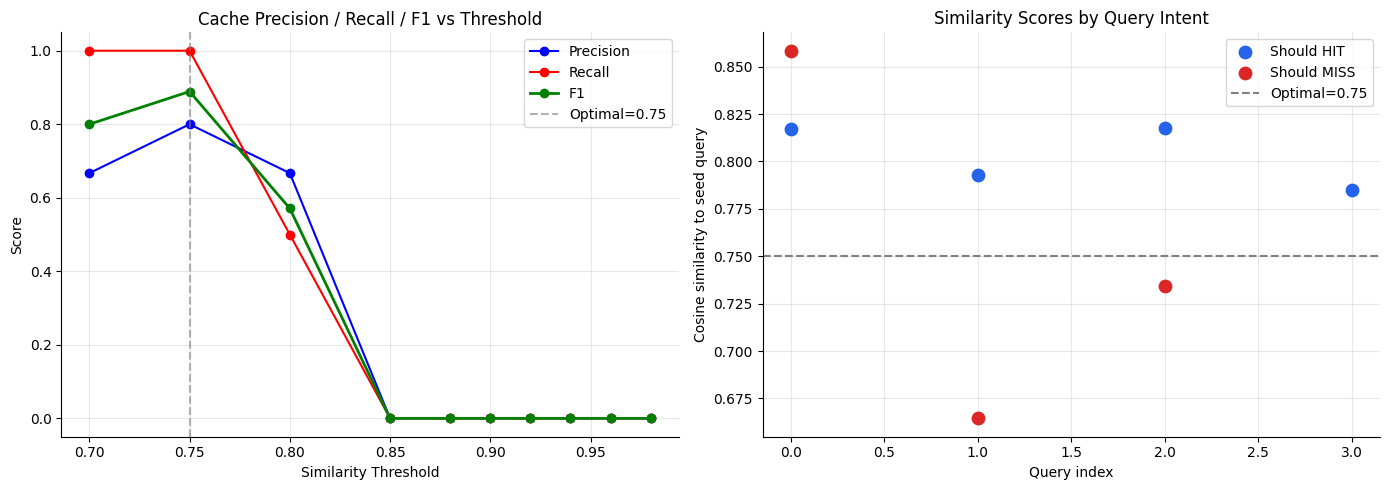

Saved cache_threshold_analysis.png
Saved results_C3_threshold.json


In [2]:
import json
import matplotlib.pyplot as plt

# Load results from C2 — no sentence_transformers needed
with open("results_C2_semantic_cache.json") as f:
    c2 = json.load(f)

results = c2["results"]
data = [(r["id"], r["similarity"], r["expected"]) for r in results if r["similarity"] is not None]

thresholds = [0.70, 0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98]

print(f"{'Threshold':>10}  {'TP':>4}  {'FP':>4}  {'TN':>4}  {'FN':>4}  {'Precision':>10}  {'Recall':>8}  {'F1':>6}")
print("-"*65)

threshold_results = []
for thresh in thresholds:
    tp = fp = tn = fn = 0
    for _, sim, expected in data:
        predicted = "HIT" if sim >= thresh else "MISS"
        if predicted == "HIT"  and expected == "HIT":  tp += 1
        if predicted == "HIT"  and expected == "MISS": fp += 1
        if predicted == "MISS" and expected == "MISS": tn += 1
        if predicted == "MISS" and expected == "HIT":  fn += 1
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
    print(f"{thresh:>10.2f}  {tp:>4}  {fp:>4}  {tn:>4}  {fn:>4}  {precision:>10.3f}  {recall:>8.3f}  {f1:>6.3f}")
    threshold_results.append({"threshold":thresh,"tp":tp,"fp":fp,"tn":tn,"fn":fn,
                               "precision":round(precision,3),"recall":round(recall,3),"f1":round(f1,3)})

best = max(threshold_results, key=lambda x: x["f1"])
print(f"\nOptimal threshold: {best['threshold']}  (F1={best['f1']})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts = [r["threshold"] for r in threshold_results]
axes[0].plot(ts, [r["precision"] for r in threshold_results], "b-o", label="Precision")
axes[0].plot(ts, [r["recall"]    for r in threshold_results], "r-o", label="Recall")
axes[0].plot(ts, [r["f1"]        for r in threshold_results], "g-o", label="F1", linewidth=2)
axes[0].axvline(best["threshold"], color="gray", linestyle="--", alpha=0.6,
                label=f"Optimal={best['threshold']}")
axes[0].set_xlabel("Similarity Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Cache Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

hit_sims  = [r["similarity"] for r in results if r["expected"]=="HIT"  and r["similarity"]]
miss_sims = [r["similarity"] for r in results if r["expected"]=="MISS" and r["similarity"]]
axes[1].scatter(range(len(hit_sims)),  hit_sims,  color="#2563eb", s=80, label="Should HIT",  zorder=3)
axes[1].scatter(range(len(miss_sims)), miss_sims, color="#dc2626", s=80, label="Should MISS", zorder=3)
axes[1].axhline(best["threshold"], color="gray", linestyle="--",
                label=f"Optimal={best['threshold']}")
axes[1].set_xlabel("Query index")
axes[1].set_ylabel("Cosine similarity to seed query")
axes[1].set_title("Similarity Scores by Query Intent")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cache_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cache_threshold_analysis.png")

with open("results_C3_threshold.json","w") as f:
    json.dump({"optimal_threshold":best["threshold"],"results":threshold_results}, f, indent=2)
print("Saved results_C3_threshold.json")

In [1]:
import time, json, sys, os
import numpy as np

CANDIDATES = [
    '/Users/srujanakadambari/Desktop/ffresh thesis/data-to-visual/data-to-visual-nicos-branch',
    os.getcwd(),
]
PROJECT_ROOT = next(
    (p for p in CANDIDATES if os.path.isfile(os.path.join(p, 'generate_visualization.py'))),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("generate_visualization.py not found.")
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Load results from C2
with open("results_C2_semantic_cache.json") as f:
    c2 = json.load(f)

results = c2["results"]

# Extract similarity scores with their ground truth labels
# We know which queries SHOULD hit (same intent) and which should miss (different intent)
data = [(r["id"], r["similarity"], r["expected"]) for r in results if r["similarity"] is not None]

# Test multiple thresholds
thresholds = [0.70, 0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98]

print(f"{'Threshold':>10}  {'TP':>4}  {'FP':>4}  {'TN':>4}  {'FN':>4}  {'Precision':>10}  {'Recall':>8}  {'F1':>6}")
print("-"*65)

threshold_results = []
for thresh in thresholds:
    tp = fp = tn = fn = 0
    for _, sim, expected in data:
        if sim is None:
            continue
        predicted = "HIT" if sim >= thresh else "MISS"
        if predicted == "HIT"  and expected == "HIT":  tp += 1
        if predicted == "HIT"  and expected == "MISS": fp += 1
        if predicted == "MISS" and expected == "MISS": tn += 1
        if predicted == "MISS" and expected == "HIT":  fn += 1

    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
    print(f"{thresh:>10.2f}  {tp:>4}  {fp:>4}  {tn:>4}  {fn:>4}  {precision:>10.3f}  {recall:>8.3f}  {f1:>6.3f}")
    threshold_results.append({"threshold":thresh,"tp":tp,"fp":fp,"tn":tn,"fn":fn,
                               "precision":round(precision,3),"recall":round(recall,3),"f1":round(f1,3)})

# Find optimal threshold (max F1)
best = max(threshold_results, key=lambda x: x["f1"])
print(f"\nOptimal threshold: {best['threshold']}  (F1={best['f1']})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts = [r["threshold"] for r in threshold_results]
axes[0].plot(ts, [r["precision"] for r in threshold_results], "b-o", label="Precision")
axes[0].plot(ts, [r["recall"]    for r in threshold_results], "r-o", label="Recall")
axes[0].plot(ts, [r["f1"]        for r in threshold_results], "g-o", label="F1", linewidth=2)
axes[0].axvline(best["threshold"], color="gray", linestyle="--", alpha=0.6,
                label=f"Optimal={best['threshold']}")
axes[0].set_xlabel("Similarity Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Cache Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Similarity score distribution
hit_sims  = [r["similarity"] for r in results if r["expected"]=="HIT"  and r["similarity"]]
miss_sims = [r["similarity"] for r in results if r["expected"]=="MISS" and r["similarity"]]
axes[1].scatter(range(len(hit_sims)),  hit_sims,  color="#2563eb", s=80, label="Should HIT",  zorder=3)
axes[1].scatter(range(len(miss_sims)), miss_sims, color="#dc2626", s=80, label="Should MISS", zorder=3)
axes[1].axhline(best["threshold"], color="gray", linestyle="--",
                label=f"Optimal threshold={best['threshold']}")
axes[1].set_xlabel("Query index")
axes[1].set_ylabel("Cosine similarity to seed query")
axes[1].set_title("Similarity Scores by Query Intent")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cache_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved cache_threshold_analysis.png")

with open("results_C3_threshold.json","w") as f:
    json.dump({"optimal_threshold":best["threshold"],"results":threshold_results}, f, indent=2)


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/srujanakadambari/anaconda3/envs/thesis/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/srujanakadambari/anaconda3/envs/thesis/lib/python3.11/site-p

NameError: name 'nn' is not defined